### Research and Report Hierarchical Agent Teams System

A supervisor agent's work is to route between different work nodes. But when job becomes complex or there is a large number of workers it becomes difficult for the supervisor to effectively call the correct worker node.

For such cases hierarchically distributed architecture works best. We can build this by composing different sub-graphs and creating a top-level supervisor along with mid-level supervisors.

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.tools import tool
from langchain_groq import ChatGroq

openai_llm = ChatOpenAI(model='gpt-4o-mini')

quen_llm = ChatGroq(model='qwen/qwen3-32b')

## Building Research Team Tools

In [3]:
tavily_tool = TavilySearchResults(max_results = 5)

In [4]:
from typing import Annotated, TypedDict, Literal, Any
from langchain_core.language_models.chat_models import BaseChatModel
from langgraph.graph import MessagesState, MessageGraph, START,END, StateGraph
from langgraph.types import Command

class State(MessagesState):
    next: str

# def make_research_supervisor(quen_llm:BaseChatModel, members: list[str]) -> str:
#     print('<-- Research Supervisor -->')
    
#     node_members = members + ['FINISH']
#     print(node_members)

In [34]:
def make_supervisor_node(llm:BaseChatModel, members:list[str], system_prompt:str) ->str:
    
    members_list=members+['FINISH']
    
    class RouterSupervisor(TypedDict):
        next: Literal[*members_list]
        
    def supervisor_node(state:State) -> Command[Literal[*members,"__end__"]]:
        
        message = [{'role':'system','content':system_prompt}]+state['messages']
        
        llm_with_structured_output = llm.with_structured_output(RouterSupervisor)
        response = llm_with_structured_output.invoke(message)
        
        goto = response['next']
        
        if goto=='FINISH':
            goto=END
        return Command(goto=goto, update={'next':goto})
    return supervisor_node

In [35]:
members = ['general_researcher','finance_researcher','medical_researcher','FINISH']
system_prompt = f"""
    You are a supervisor managing a task delegation system with the following workers: {members}.

    Your job is to decide which worker should act next based on the user’s input.

    Guidelines:
    - If the message is about stocks, shares, company performance, financial comparison, or anything related to companies or markets, assign it to finance_researcher.
    - If the message is related to finance, assign finance_researcher.
    - If the message is related to medical or medicine science, assign medical_researcher.
    - If the message is related to general research, assign general_researcher.
    - Once all the tasks are completed respond with FINISH.
    - Do **not** invent tasks or assign actions unless the message clearly demands it.

    **Examples:**
    - "Compare Microsoft and Nvidia shares for today's price" → finance_researcher
    - "What is the latest on Apple stock?" → finance_researcher
    - "What are the symptoms of flu?" → medical_researcher
    - "Explain quantum computing" → general_researcher

    Each worker will return results after completing their task.
    Once all necessary tasks are completed, end the flow by responding with `FINISH`.

    Be strict — if the message is casual, rhetorical, or lacks a clear task, reply with `FINISH`.
"""
research_supervisor_node = make_supervisor_node(openai_llm,members,system_prompt)

In [36]:
research_supervisor_node

<function __main__.make_supervisor_node.<locals>.supervisor_node(state: __main__.State) -> langgraph.types.Command[typing.Literal['general_researcher', 'finance_researcher', 'medical_researcher', 'FINISH', '__end__']]>

In [13]:
members = ['general_researcher','finance_researcher','medical_researcher','FINISH']
system_prompt = f"""
    You are a supervisor managing a task delegation system with the following workers: {members}.

    Your job is to decide which worker should act next based on the user’s input.

    Guidelines:
    - If the message is about stocks, shares, company performance, financial comparison, or anything related to companies or markets, assign it to finance_researcher.
    - If the message is related to finance, assign finance_researcher.
    - If the message is related to medical or medicine science, assign medical_researcher.
    - If the message is related to general research, assign general_researcher.
    - Once all the tasks are completed respond with FINISH.
    - Do **not** invent tasks or assign actions unless the message clearly demands it.

    **Examples:**
    - "Compare Microsoft and Nvidia shares for today's price" → finance_researcher
    - "What is the latest on Apple stock?" → finance_researcher
    - "What are the symptoms of flu?" → medical_researcher
    - "Explain quantum computing" → general_researcher

    Each worker will return results after completing their task.
    Once all necessary tasks are completed, end the flow by responding with `FINISH`.

    Be strict — if the message is casual, rhetorical, or lacks a clear task, reply with `FINISH`.
"""
        
    
class RouterResearch(TypedDict):
    next: Literal['general_researcher','finance_researcher','medical_researcher','FINISH']
        
    
def research_supervisor(state:State) -> Command[Literal['general_researcher','finance_researcher','medical_researcher','__end__']]:
    print('<-- Researcher Supervisor -->')
    
    messages = [{'role':'system','content':system_prompt}] + state['messages']
    
    response = openai_llm.with_structured_output(RouterResearch).invoke(messages)
    
    goto = response['next']
    
    print("*********Below is my GOTO*****************")
    
    print(goto)
    
    if goto =='FINISH':
        goto=END
    
    return Command(goto=goto, update={'next':goto})



In [37]:
research_supervisor

<function __main__.research_supervisor(state: __main__.State) -> langgraph.types.Command[typing.Literal['general_researcher', 'finance_researcher', 'medical_researcher', '__end__']]>

##### Research Agents

In [14]:
from langchain import hub
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import HumanMessage, AIMessage


def general_research(state:State) -> Command[Literal['supervisor']]:
    print('<-- General Researcher -->')
    
    prompt = 'You are a researcher who researches on general topics only.Do a through research on the query provided'
    tavily_agent = create_react_agent(quen_llm, tools= [tavily_tool],prompt=prompt)
    
    result = tavily_agent.invoke(state)
    return Command(
        goto='supervisor',
        update={'messages':[HumanMessage(content=result['messages'][-1].content, name='general_researcher')]}
    )

In [16]:
from langchain_community.retrievers import PubMedRetriever
from langchain.tools.retriever import create_retriever_tool

def medical_research(state:State) -> Command[Literal['supervisor']]:
    print('<-- Medical Researcher -->')
    
    prompt = 'You are a researcher who researches on Medical topics only.Do a through research on the query provided'
    
    retriever = PubMedRetriever()

    medical_retriever_tool = create_retriever_tool(
        retriever=retriever,
        name = 'medical_researcher',
        description='''
        You are a expert in medical research. 
        Search and return information about user query related to medicine, medical emergencies and medications to take.
        '''
    )
    medical_agent = create_react_agent(quen_llm, tools= [medical_retriever_tool,tavily_tool],prompt=prompt)
    
    result = medical_agent.invoke(state)
    return Command(
        goto='supervisor',
        update={'messages':[HumanMessage(content=result['messages'][-1].content, name='medical_researcher')]}
    )

In [17]:
from langchain_community.tools.yahoo_finance_news import YahooFinanceNewsTool
from langchain_core.prompts import PromptTemplate
import yfinance as yf

yfinance =YahooFinanceNewsTool()

@tool
def get_stock_price(ticker:str) -> str:
    '''
    Fetch the last closed price of the given stock ticker.
    If the user provides a company name, use the correct ticker symbol (e.g., Microsoft=MSFT, Nvidia=NVDA).
    '''
    dat = yf.Ticker(ticker)
    previous_close_price = dat.info.get('previousClose')
    previous_open_price = dat.info.get('open')
    day_high = dat.info.get('dayHigh')
    day_low = dat.info.get('dayLow')
    if previous_close_price is None:
        return f'Could not fetch price detail for {ticker}'
    return f'Last closing price for {ticker} was ${previous_close_price} with day open price ${previous_open_price} and day highest ${day_high} and day lowest ${day_low}.'
    

def finance_research(state:State) -> Command[Literal['supervisor']]:
    print('<-- Finance Researcher -->')
    
    prompt = "You are a researcher who is an expert on Financial Topics only. Do a through research on the query provided."
            
    yfinance_agent = create_react_agent(quen_llm,tools=[yfinance,get_stock_price], prompt=prompt)
    print(state)
    
    response = yfinance_agent.invoke(state)
    #print(response['messages'][-1].content)
    
    return Command(
        goto='supervisor',
        update={'messages':[HumanMessage(content=response['messages'][-1].content, name='finance_researcher')]}
    )
    
#research_supervisor_node = make_research_supervisor(quen_llm,['general_researcher','finance_researcher'])

In [18]:
## Building Research Graph

research_builder = StateGraph(State)
research_builder.add_node('supervisor', research_supervisor)
research_builder.add_node('general_researcher', general_research)
research_builder.add_node('finance_researcher',finance_research)
research_builder.add_node('medical_researcher', medical_research)

## Logic
research_builder.add_edge(START,'supervisor')

## Compile
research_app = research_builder.compile()

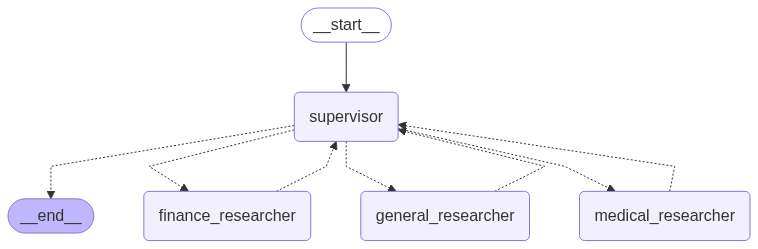

In [19]:
research_app

In [20]:
message = [HumanMessage(content="How did Nvidia stock performed today in comparision to Microsoft")]
response =  research_app.invoke({'messages':message})
print(response)

<-- Researcher Supervisor -->
*********Below is my GOTO*****************
finance_researcher
<-- Finance Researcher -->
{'messages': [HumanMessage(content='How did Nvidia stock performed today in comparision to Microsoft', additional_kwargs={}, response_metadata={}, id='216d8099-49cd-4a86-9b4a-1908fd2908ff')], 'next': 'finance_researcher'}
<-- Researcher Supervisor -->
*********Below is my GOTO*****************
FINISH
{'messages': [HumanMessage(content='How did Nvidia stock performed today in comparision to Microsoft', additional_kwargs={}, response_metadata={}, id='216d8099-49cd-4a86-9b4a-1908fd2908ff'), HumanMessage(content="Here's a comparison of today's performance for **Nvidia (NVDA)** and **Microsoft (MSFT)**:\n\n### **Nvidia (NVDA)**\n- **Opening Price**: $158.35  \n- **Day High**: $160.98  \n- **Day Low**: $157.77  \n- **Closing Price**: $157.25  \n\n### **Microsoft (MSFT)**\n- **Opening Price**: $493.50  \n- **Day High**: $500.12  \n- **Day Low**: $493.44  \n- **Closing Price**

In [21]:
response['messages'][-1].pretty_print()

================================ Human Message =================================
Name: finance_researcher

Here's a comparison of today's performance for **Nvidia (NVDA)** and **Microsoft (MSFT)**:

### **Nvidia (NVDA)**
- **Opening Price**: $158.35  
- **Day High**: $160.98  
- **Day Low**: $157.77  
- **Closing Price**: $157.25  

### **Microsoft (MSFT)**
- **Opening Price**: $493.50  
- **Day High**: $500.12  
- **Day Low**: $493.44  
- **Closing Price**: $491.09  

### **Key Observations**:
1. **Nvidia**: Closed **-0.70%** below its opening price, with a relatively narrow intraday range.  
2. **Microsoft**: Closed **-0.46%** below its opening price, showing a wider intraday swing (peaking at $500.12) but closed lower.  

Both stocks ended the day slightly below their opening prices, but **Microsoft had a higher peak** during the day. For deeper insights, you could check news or sector trends affecting these stocks. Let me know if you'd like further analysis!


In [22]:
message = [HumanMessage(content="I am having head pain. What medicine can I take?")]
response = research_app.invoke({'messages':message})
print(response)

<-- Researcher Supervisor -->
*********Below is my GOTO*****************
medical_researcher
<-- Medical Researcher -->
<-- Researcher Supervisor -->
*********Below is my GOTO*****************
FINISH
{'messages': [HumanMessage(content='I am having head pain. What medicine can I take?', additional_kwargs={}, response_metadata={}, id='827c404c-3aec-4dd6-9f4b-fe4c30ab4e57'), HumanMessage(content="For headache or mild head pain, over-the-counter (OTC) medications are commonly used, but their selection and frequency of use should be guided by the type and severity of the headache. Here's a summary based on recent research and clinical guidelines:\n\n---\n\n### **Common OTC Medications for Headaches**\n1. **Analgesics/Anti-inflammatory Drugs**:\n   - **Ibuprofen** (e.g., Advil, Motrin): Effective for tension-type headaches and migraines.\n   - **Acetaminophen** (e.g., Tylenol): Often recommended for mild to moderate headaches.\n   - **Aspirin**: Used for headaches but associated with a higher

In [23]:
response['messages'][-1].pretty_print()

================================ Human Message =================================
Name: medical_researcher

For headache or mild head pain, over-the-counter (OTC) medications are commonly used, but their selection and frequency of use should be guided by the type and severity of the headache. Here's a summary based on recent research and clinical guidelines:

---

### **Common OTC Medications for Headaches**
1. **Analgesics/Anti-inflammatory Drugs**:
   - **Ibuprofen** (e.g., Advil, Motrin): Effective for tension-type headaches and migraines.
   - **Acetaminophen** (e.g., Tylenol): Often recommended for mild to moderate headaches.
   - **Aspirin**: Used for headaches but associated with a higher risk of gastrointestinal side effects.

2. **Combination Medications**:
   - Some OTC drugs combine analgesics with caffeine (e.g., Excedrin) to enhance pain relief.

3. **Triptans** (Prescription-Only for Migraines):
   - Medications like **sumatriptan** are specifically designed for migraines 

#### Document Writing Team

In [24]:
from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Optional,List, Annotated
from langchain_experimental.utilities import PythonREPL

dir_name = 'outputfiles'
os.makedirs(dir_name,exist_ok=True)

@tool
def create_outine(
    points: Annotated[List[str], "List of main points and sections."],
    file_name: Annotated[str, "File name to save the outline"]
) -> Annotated[str,"Path of saved outline file"]:
    """ Create and saved the outline of the document"""
    print('create_outline')
    print(points)
    full_path = os.path.join(dir_name,file_name)
    with open(full_path,'w') as file:
        for i, point in enumerate(points):
            file.write(f"{i+1}.{point}\n")
    return f"Outline saved to {full_path}"

@tool
def read_document(
    file_name: Annotated[str, "File name to read the document from"],
    start: Annotated[Optional[int], 'The start line. Default is 0']=None,
    end: Annotated[Optional[int],' The end line. Default is None'] = None
) -> str:
    '''Read the specific document'''
    print('read_document')
    full_path = os.path.join(dir_name, file_name)
    with open(full_path,'r') as file:
        lines = file.readlines()
    if start is None:
        start=0
    return "\n".join(lines[start:end])

@tool
def write_document(
    content: Annotated[str,"Text content to be written into the document"],
    file_name: Annotated[str,"File name to save the document"]
) -> Annotated[str,"Path of the saved document"]:
    '''Create and save the text document'''
    print('write_document')
    file_path = os.path.join(dir_name,file_name)
    with open(file_path,'w') as file:
        file.write(content)
    return f"Document saved to {file_path}"

@tool
def edit_document(
    file_name: Annotated[str,"File name of the document to be edited"],
    inserts: Annotated[Dict[int,str],"Dictionary where key is the line number (1-indexed) and value is the text to be inserted at that line"]
) ->Annotated[str,"Path of saved outline file"]:
    '''Edit the document by inserting the text and charts at specific numbers'''
    print('edit_document')
    
    full_path = os.path.join(dir_name, file_name)
    with open(full_path,'r') as file:
        lines = file.readlines()
        
    sorted_inserts = sorted(inserts.items())
    new_lines = list(lines)
    offset =0
    for line_number, text in sorted_inserts:
        if 1<=line_number<=len(line_number)+1:
            new_lines.insert(line_number-1 + offset,text+"\n")
            offset+=1
        else:
            return f"Error: Line number {line_number} is out of range"
    
    with open(full_path,'w') as file:
        file.writelines(new_lines)
    return f"Document {file_name} edited and saved to {full_path}"
        
@tool
def python_repl_tool(code: Annotated[str, "The python code to execute and generate your chart"]):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    print('python_repl_tool')
    try:
        repl = PythonREPL()
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    result_str = f"Successfully executed: \n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return result_str

@tool
def summarize_content(
    content: Annotated[str,"The content provided by researcher team to be summarized"]
) -> str:
    '''Summarize the content provided to you in a proper format'''
    print('summarize_content')
    
    prompt_template = PromptTemplate('You are an expert summarizer, your task is to format the content provided in markdown format: \n\n {content}')
    
    chain = prompt_template | quen_llm
    response = chain.invoke(content)
    return f"Summarized Content: \n {response.content}"


<>:87: SyntaxWarning: invalid escape sequence '\`'
<>:87: SyntaxWarning: invalid escape sequence '\`'
<>:87: SyntaxWarning: invalid escape sequence '\`'
<>:87: SyntaxWarning: invalid escape sequence '\`'
C:\Users\ashut\AppData\Local\Temp\ipykernel_50492\3871428278.py:87: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed: \n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
C:\Users\ashut\AppData\Local\Temp\ipykernel_50492\3871428278.py:87: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed: \n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"


In [25]:
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser

class OutlineOutput(BaseModel):
    points: List[str] = Field(description='List of main points and sections')
    file_name : str = Field(description='file name')
    

In [27]:
def doc_writing_node(state:State) -> Command[Literal['supervisor']]:
    print('<-- Document Writing Agent -->')
    
    prompt = ("You are an AI assistant that can read, write and edit documents based on a summarizer's outline."
              "Don't ask follow up questions. Use the provided tool")
    
    writing_agent = create_react_agent(
        quen_llm,
        tools=[write_document,read_document,edit_document],
        prompt=prompt
    )
    
    response = writing_agent.invoke(state)
    
    return Command(
        goto='supervisor',
        update={'messages':[HumanMessage(content=response['messages'][-1].content, name='doc_writer')]}
    )
    

def summarizing_node(state:State) -> Command[Literal['supervisor']]:
    print('<-- Summarizer Agent -->')
    
    prompt = ("ou can summarize the content provided by researcher team."
              "Don't ask follow up questions. Use the provided tools.")
    
    summerizer_agent = create_react_agent(
        quen_llm,
        tools=[summarize_content]
    )
    
    response = summerizer_agent.invoke(state)
    
    return Command(
        goto = 'supervisor',
        update={'messages':[HumanMessage(content=response['messages'][-1].content, name='summarizer')]}
    )
    


def outline_node(state:State)->Command[Literal['supervisor']]:
    print('<-- Outline Node -->')
    
    prompt = (
        "You are an expert at creating structured outlines for documents. "
            "Given the summary or content provided, you must call the `create_outine` tool "
            "with a list of main points/sections and a file name. "
            "Do NOT output anything else, just the tool call. "
            "For example, if the input is about head pain management, your tool call should look like:\n"
            "create_outine(points=['Causes', 'Symptoms', 'Treatments', 'Prevention'], file_name='head_pain_management.txt')\n"
    )
    
    outline_agent = create_react_agent(
        quen_llm,
        tools=[create_outine],
        prompt = prompt
        
    )
    response = outline_agent.invoke(state)
    return Command(
        goto='supervisor',
        update={'messages':[HumanMessage(content=response['messages'][-1].content, name='outline')]}
    )

def chart_generating_node(state:State) -> Command[Literal['supervisor']]:
    print('<-- Chart Generating Node -->')
    
    prompt = ('You are a codeing expert. You can write and execute code and generate charts. Do not do any research')
    
    chart_agent = create_react_agent(
        quen_llm,
        tools=[read_document,python_repl_tool],
        prompt=prompt
    )
    
    response = chart_agent.invoke(state)
    
    return Command(
        goto ='supervisor',
        update ={'messages':[HumanMessage(content=response['messages'][-1].content, name='chart_generator')]}
    )
    

You are a supervisor managing a task delegation system with the following workers: {members}.

Your job is to decide which worker should act next based on the user’s input.

Guidelines:
- Always follow this sequence for every new research content:
    1. First, call the summarizer to summarize the content.
    2. Next, call the outline agent to create an outline from the summary.
    3. Then, call the doc_writer to fill in the document using the outline and summary.
    4. If a chart is required, call the chart_generator.
    5. Only after all these steps, respond with FINISH.
- Do **not** skip any step in the sequence.
- Do **not** invent tasks or assign actions unless the message clearly demands it.

Each worker will return results after completing their task.
Once all necessary tasks are completed, end the flow by responding with `FINISH`.

Be strict — if the message is casual, rhetorical, or lacks a clear task, reply with `FINISH`.

### Document Supervisor

In [28]:
members = ['summarizer','outline','doc_writer','chart_generator','FINISH']
system_prompt = f"""
You are a supervisor managing a task delegation system with the following workers: {members}.

Your job is to decide which worker should act next based on the user’s input.

Guidelines:
- Always follow this sequence for every new research content:
    1. First, call the summarizer to summarize the content.
    2. Next, call the outline agent to create an outline from the summary.
    3. Then, call the doc_writer to fill in the document using the outline and summary.
    4. If a chart is required, call the chart_generator.
    5. Only after all these steps, respond with FINISH.
- Do **not** skip any step in the sequence.
- Do **not** invent tasks or assign actions unless the message clearly demands it.

Each worker will return results after completing their task.
Once all necessary tasks are completed, end the flow by responding with `FINISH`.

Be strict — if the message is casual, rhetorical, or lacks a clear task, reply with `FINISH`."""
        
    
class Router(TypedDict):
    next: Literal['summarizer','outline','doc_writer','chart_generator','FINISH']
        
    
def report_builder_supervisor(state:State) -> Command[Literal['summarizer','outline','doc_writer','chart_generator','__end__']]:
    print('<-- Report Builder Supervisor -->')
    
    messages = [{'role':'system','content':system_prompt}] + state['messages']
    
    response = openai_llm.with_structured_output(Router).invoke(messages)
    print(response)
    goto = response['next']
    
    print("*********Below is my GOTO*****************")
    
    print(goto)
    
    if goto =='FINISH':
        goto=END
    
    return Command(goto=goto, update={'next':goto})


In [29]:
report_builder = StateGraph(State)
report_builder.add_node('supervisor',report_builder_supervisor)
report_builder.add_node('summarizer',summarizing_node)
report_builder.add_node('outline', outline_node)
report_builder.add_node('doc_writer',doc_writing_node)
report_builder.add_node('chart_generator',chart_generating_node)

report_builder.add_edge(START,'supervisor')

## compile
report_app = report_builder.compile()

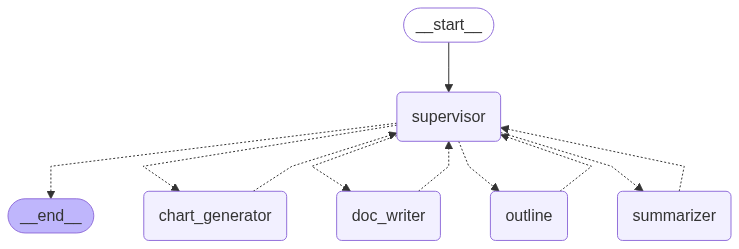

In [30]:
report_app

In [31]:
message = [
 HumanMessage(content="I'm not a doctor, but I can provide some general information based on medical research that might help you better understand your options for treating head pain. However, please remember that this information is not a substitute for personalized medical advice. Here are some points and options to consider:\n\n1. Over-the-Counter (OTC) Options:\n\u2003• Acetaminophen (paracetamol): Often used for mild to moderate head pain.\n\u2003• Nonsteroidal anti-inflammatory drugs (NSAIDs): Ibuprofen or naproxen may help reduce inflammation and pain.\n\u2003• Combination products: Some OTC medications combine acetaminophen, aspirin, and caffeine, which might be effective for some people.\n\n2. Specific Considerations Based on Head Pain Type:\n\u2003• Tension-Type Headaches: These are often treated successfully with OTC pain relievers, heat application, relaxation, or stress management techniques.\n\u2003• Migraines: In addition to pain-relief medications, migraines may require treatments specifically designed for this type of headache, such as triptans (e.g., sumatriptan) prescribed by a doctor. OTC options like NSAIDs or acetaminophen may be used if migraines are mild.\n\u2003• Cluster Headaches: These might require specific medications prescribed by your healthcare provider, such as oxygen therapy or triptans.\n\n3. Lifestyle Modifications:\n\u2003• Hydration: Dehydration is a common trigger for headaches. Drinking enough water may help.\n\u2003• Sleep: Maintaining a regular sleep schedule can reduce headache frequency.\n\u2003• Stress Management: Techniques such as relaxation exercises, meditation, and proper ergonomics can help relieve tension-related pain.\n\n4. When to See a Healthcare Provider:\n\u2003• If the head pain is severe, persistent, or worsening.\n\u2003• If headaches are accompanied by symptoms such as vision changes, confusion, dizziness, weakness, or other neurological symptoms.\n\u2003• If you notice a pattern or increase in frequency, which might suggest an underlying issue needing evaluation.\n\n5. Medical and Personal Health Considerations:\n\u2003• Always consider your existing medical conditions or any contraindications (e.g., NSAIDs may not be preferred if you have a history of gastrointestinal issues, kidney problems, or cardiovascular concerns).\n\u2003• Avoid self-medication over long periods—if you're frequently relying on any form of pain relief for head pain, it might be wise to consult with a healthcare provider.\n\nGiven that head pain can have various causes, it’s essential to observe your symptoms and history. If this head pain is a new problem, particularly if it is severe or associated with other concerning signs, please seek medical evaluation promptly.\n\nRemember, this discussion is informational and should not replace professional medical advice. If your symptoms persist or worsen, contact a healthcare professional for a thorough evaluation and tailored treatment recommendations.")]
for s in report_app.stream({'messages':message}):
    print(s)
    print("-----")

<-- Report Builder Supervisor -->
{'next': 'summarizer'}
*********Below is my GOTO*****************
summarizer
{'supervisor': {'next': 'summarizer'}}
-----
<-- Summarizer Agent -->
summarize_content
summarize_content


BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<tool_call>\n{"name": "summarize_content", "arguments": "The text provides general non-medical advice for managing head pain, covering OTC options (acetaminophen, NSAIDs), headache-specific treatments (tension, migraines, cluster headaches), lifestyle adjustments (hydration, sleep, stress), when to seek medical care (severe/persistent symptoms), and health precautions (contraindications, avoiding long-term self-medication). It emphasizes this is not a substitute for professional advice."}\n</tool_call>'}}

### Creating Head Supervisor


In [ ]:
class RouterMain(TypedDict):
    next: Literal['research_team','report_team'
                  ,'FINISH']

def head_supervisor(state:State) ->Command[Literal['research_team','report_team', '__end__']]:
    print("<-- Head Supervisor -->")
    
    system_prompt = """
    You are a head supervisor agent responsible for orchestrating two specialized teams: the research team and the report team.

    - The **research team** is responsible for gathering, searching, and summarizing information based on user queries.
    - The **report team** is responsible for generating structured outlines, writing, editing, and formatting documents based on research outputs.

    **Guidelines:**
    1. For every user query that requires research, you must always call the research team first.
    2. After the research team completes, you must always call the report team to generate a report, regardless of the research content.
    3. Only after both teams have completed their tasks, respond with FINISH.
    4. Do not skip any steps or invent tasks.
    5. If the user message is casual, rhetorical, or does not require research or reporting, respond with FINISH.

    **Your job is to decide which team should act next based on the current state of the workflow. Only route to one team at a time.**

    Return one of: `research_team`, `report_team`, or `FINISH`."""
    
    messages = [{'role':'system','content':system_prompt}] + state['messages']
    
    
    quen_llm_with_structured_output=quen_llm.with_structured_output(RouterMain)
    response = quen_llm_with_structured_output.invoke(messages)
    
    goto=response['next']
    print("*********Below is my GOTO*****************")
    print(goto)
    
    if goto == 'FINISH':
        goto= END
    return Command(
        goto=goto,
        update={'next':goto}
    )
    

In [105]:
def call_research_team(state:State)->Command[Literal['supervisor']]:
    print('<-- Calling Research Team -->')
    response = research_app.invoke({'messages':state['messages']})
    print(response['messages'][-1].content)
    new_messages = state['messages'] + [HumanMessage(content=response['messages'][-1].content, name='research_team')]
    return Command(
        goto='supervisor',
        update={'messages':new_messages}
    )
    
def call_report_team(state:State)->Command[Literal['supervisor']]:
    print('<-- Calling Report Team -->')
    response = report_app.invoke({'messages':state['messages']})
    new_messages = state['messages'] + [HumanMessage(content=response['messages'][-1].content, name='report_team')]
    return Command(
        goto='supervisor',
        update={'messages':new_messages}
    )

In [106]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
## Build Graph
super_builder = StateGraph(State)
super_builder.add_node('supervisor',head_supervisor)
super_builder.add_node('research_team', call_research_team)
super_builder.add_node('report_team', call_report_team)

#Logic
super_builder.add_edge(START,'supervisor')

## Compile
research_report_app = super_builder.compile(checkpointer=memory)

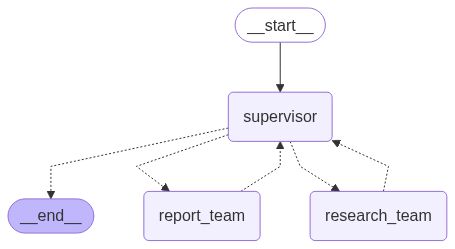

In [107]:
from IPython.display import Image, display

display(Image(research_report_app.get_graph().draw_mermaid_png()))

Compare Microsoft and Nvidia shares for last 2 days

In [109]:
config = {'configurable':{'thread_id':'1'}}
message = [HumanMessage(content='How did Nvidia stock performed today in comparision to Microsoft')]
for s in research_report_app.invoke({'messages':message}, config=config):
    print(s)
    print("-----------")

<-- Head Supervisor -->
*********Below is my GOTO*****************
research_team
<-- Calling Research Team -->
<-- Researcher Supervisor -->
*********Below is my GOTO*****************
FINISH
How did Nvidia stock performed today in comparision to Microsoft
<-- Head Supervisor -->
*********Below is my GOTO*****************
research_team
<-- Calling Research Team -->
<-- Researcher Supervisor -->
*********Below is my GOTO*****************
FINISH
How did Nvidia stock performed today in comparision to Microsoft
<-- Head Supervisor -->
*********Below is my GOTO*****************
report_team
<-- Calling Report Team -->
<-- Report Builder Supervisor -->
{'next': 'FINISH'}
*********Below is my GOTO*****************
FINISH
<-- Head Supervisor -->
*********Below is my GOTO*****************
research_team
<-- Calling Research Team -->
<-- Researcher Supervisor -->
*********Below is my GOTO*****************
FINISH
How did Nvidia stock performed today in comparision to Microsoft
<-- Head Supervisor --

GraphRecursionError: Recursion limit of 25 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/GRAPH_RECURSION_LIMIT